








# Mercado Justo — Predicción de Precios del Café

| Sección | Contenido | Materia |
|---|---|---|
| 0 | Configuración del entorno | — |
| 1 | Carga, limpieza y EDA con PySpark | Minería de Datos + Almacenamiento |
| 2 | Pronóstico con ARIMA | Modelos Estocásticos |
| 3 | Clasificación con Random Forest | Aprendizaje Máquina |
| 4 | Optimización lineal (PuLP) | Investigación de Operaciones |
| 5 | Dashboard interactivo | Mercadotecnia Digital |
| 6 | Arquitectura Big Data | Herramientas de Almacenamiento |

**Fuentes:** SIAP (Excel local) · ICE Futures KC=F (API Yahoo Finance) · USD/MXN (API Yahoo Finance)


## Sección 0 — Configuración del entorno

In [ ]:
# ── Instalar dependencias ───────────────────────────────────────────────────
# Funciona tanto en Google Colab como en Jupyter local (Linux).
import subprocess, sys
paquetes = ['pyspark','yfinance','pmdarima','PuLP','statsmodels',
            'plotly','openpyxl','scikit-learn','joblib']
for p in paquetes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', p])
print("Dependencias instaladas ✓")

Dependencias instaladas ✓


In [ ]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, mean_absolute_error, mean_squared_error)
import pulp
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4.5)

PALETA = {
    "productor": "#6F4E37", "futuros": "#C19A6B",
    "consumidor": "#2E8B57", "acento": "#D2691E", "neutro": "#8C8C8C",
}
print("Imports completados ✓")

Imports completados ✓


In [ ]:
# ── Crear sesión de Spark ───────────────────────────────────────────────────
spark = (SparkSession.builder
         .appName("MercadoJustoCafe")
         .config("spark.sql.repl.eagerEval.enabled", True)
         .config("spark.sql.repl.eagerEval.maxNumRows", 10)
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} — sesión lista ✓")

Spark 4.0.2 — sesión lista ✓


## Sección 1 — Carga, limpieza y EDA con PySpark
**Materia:** Minería de Datos + Herramientas de Almacenamiento


### 1.1 — Extracción de datos

In [ ]:
# ── SIAP (datos del productor) ─────────────────────────────────────────────
siap_pd = pd.read_excel("cafe_cereza_2003_2024.xlsx")
siap = spark.createDataFrame(siap_pd)
print(f"SIAP cargado: {siap.count()} filas")

# Eliminar filas de resumen del SIAP (Municipio = "TOTAL")
filas_total = siap.filter(F.upper(F.col("Municipio")).contains("TOTAL")).count()
siap = siap.filter(~F.upper(F.col("Municipio")).contains("TOTAL"))
print(f"Filas de resumen eliminadas: {filas_total}")
print(f"SIAP limpio: {siap.count()} filas")

# ── KC=F desde Yahoo Finance (API en vivo) ─────────────────────────────────
print("\nDescargando KC=F...")
kc_pd = yf.download("KC=F", start="2000-01-01", progress=False, auto_adjust=False)
if isinstance(kc_pd.columns, pd.MultiIndex):
    kc_pd.columns = kc_pd.columns.get_level_values(0)
kc_pd = kc_pd[['Close']].rename(columns={'Close': 'kc_usd_lb'}).reset_index()
kc_pd['Date'] = pd.to_datetime(kc_pd['Date']).dt.tz_localize(None)

# ⚠️ Yahoo Finance reporta KC=F en CENTAVOS de dólar, no en dólares
kc_pd['kc_usd_lb'] = kc_pd['kc_usd_lb'] / 100.0
print(f"KC=F: {len(kc_pd)} días — último: {kc_pd['kc_usd_lb'].iloc[-1]:.2f} USD/lb")

# ── Tipo de cambio USD/MXN ─────────────────────────────────────────────────
print("\nDescargando USD/MXN...")
fx_pd = yf.download("USDMXN=X", start="2000-01-01", progress=False, auto_adjust=False)
if isinstance(fx_pd.columns, pd.MultiIndex):
    fx_pd.columns = fx_pd.columns.get_level_values(0)
fx_pd = fx_pd[['Close']].rename(columns={'Close': 'usdmxn'}).reset_index()
fx_pd['Date'] = pd.to_datetime(fx_pd['Date']).dt.tz_localize(None)

# Unir precios en Spark
kc_spark = spark.createDataFrame(kc_pd)
fx_spark = spark.createDataFrame(fx_pd)
precios_spark = kc_spark.join(fx_spark, on='Date', how='left').orderBy('Date').dropna()
print(f"\nSerie unificada: {precios_spark.count()} días")

SIAP cargado: 7270 filas
Filas de resumen eliminadas: 1
SIAP limpio: 7269 filas

Descargando KC=F...
KC=F: 6616 días — último: 2.64 USD/lb

Descargando USD/MXN...

Serie unificada: 5637 días


### 1.2 — Análisis exploratorio

In [ ]:
# ── Diagnóstico cuantitativo ───────────────────────────────────────────────
print(f"Registros: {siap.count():,}")
print(f"Estados: {[r['Estado'] for r in siap.select('Estado').distinct().collect()]}")
anio_min = siap.agg(F.min('Anio')).collect()[0][0]
anio_max = siap.agg(F.max('Anio')).collect()[0][0]
print(f"Años: {anio_min} → {anio_max}")
print(f"Municipios: {siap.select('Municipio').distinct().count()}")
print(f"Precios en cero: {siap.filter(F.col('Precio_medio_rural')==0).count()}")
print("\nResumen estadístico:")
siap.select('Sup_sembrada','Sup_cosechada','Produccion',
            'Rendimiento','Precio_medio_rural').describe().show()

Registros: 7,269
Estados: ['Veracruz', 'Chiapas', 'Oaxaca']
Años: 2003 → 2024
Municipios: 346
Precios en cero: 38

Resumen estadístico:
+-------+------------------+------------------+-----------------+------------------+------------------+
|summary|      Sup_sembrada|     Sup_cosechada|       Produccion|       Rendimiento|Precio_medio_rural|
+-------+------------------+------------------+-----------------+------------------+------------------+
|  count|              7269|              7269|             7269|              7269|              7269|
|   mean| 1665.273638739853| 1550.669413949649|2644.288195074974|1.5346540101802189|4419.0304058329875|
| stddev|2748.0553435091774|2640.3479959121028|5396.284473500086|0.8437947978148638|1792.3075436248605|
|    min|               3.0|               0.0|              0.0|               0.0|               0.0|
|    max|          27780.43|          27774.48|         89130.38|               6.0|           14000.0|
+-------+------------------+----

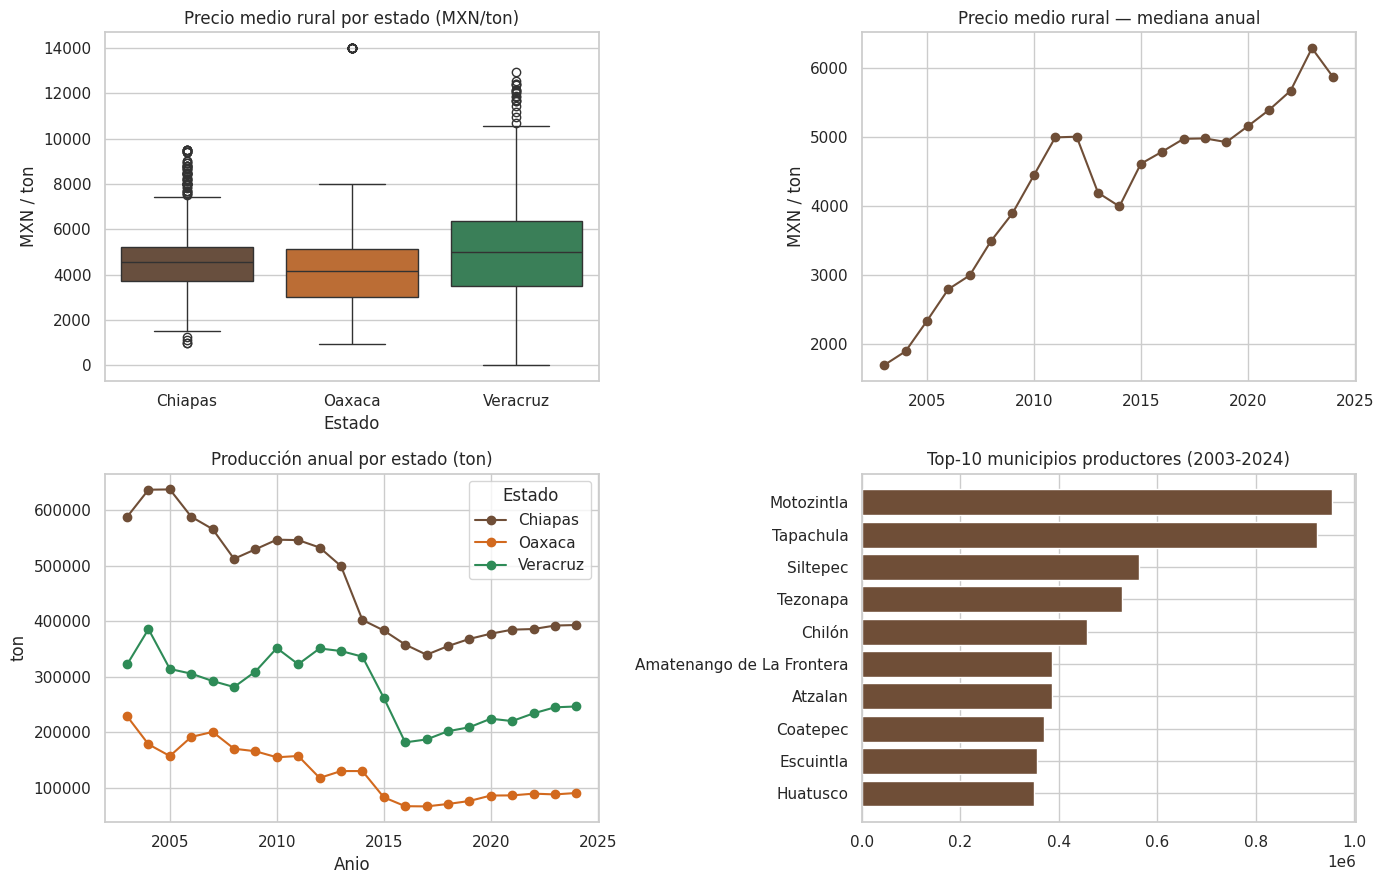

In [ ]:
# ── EDA visual: 4 paneles ──────────────────────────────────────────────────
df_box = siap.filter(F.col('Precio_medio_rural') > 0).select('Estado','Precio_medio_rural').toPandas()
df_anual = (siap.filter(F.col('Precio_medio_rural') > 0)
                .groupBy('Anio')
                .agg(F.expr('percentile_approx(Precio_medio_rural, 0.5)').alias('mediana'))
                .orderBy('Anio').toPandas())
df_prod = (siap.groupBy('Anio','Estado').agg(F.sum('Produccion').alias('prod'))
               .toPandas().pivot(index='Anio', columns='Estado', values='prod'))
df_top10 = (siap.groupBy('Municipio').agg(F.sum('Produccion').alias('prod'))
                .orderBy(F.col('prod').desc()).limit(10).toPandas().sort_values('prod'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.boxplot(data=df_box, x='Estado', y='Precio_medio_rural', ax=axes[0,0],
            palette=[PALETA['productor'], PALETA['acento'], PALETA['consumidor']])
axes[0,0].set_title("Precio medio rural por estado (MXN/ton)")
axes[0,0].set_ylabel("MXN / ton")

axes[0,1].plot(df_anual['Anio'], df_anual['mediana'], marker='o', color=PALETA['productor'])
axes[0,1].set_title("Precio medio rural — mediana anual"); axes[0,1].set_ylabel("MXN / ton")

df_prod.plot(ax=axes[1,0], marker='o',
             color=[PALETA['productor'], PALETA['acento'], PALETA['consumidor']])
axes[1,0].set_title("Producción anual por estado (ton)"); axes[1,0].set_ylabel("ton")

axes[1,1].barh(df_top10['Municipio'], df_top10['prod'], color=PALETA['productor'])
axes[1,1].set_title("Top-10 municipios productores (2003-2024)")
plt.tight_layout(); plt.show()

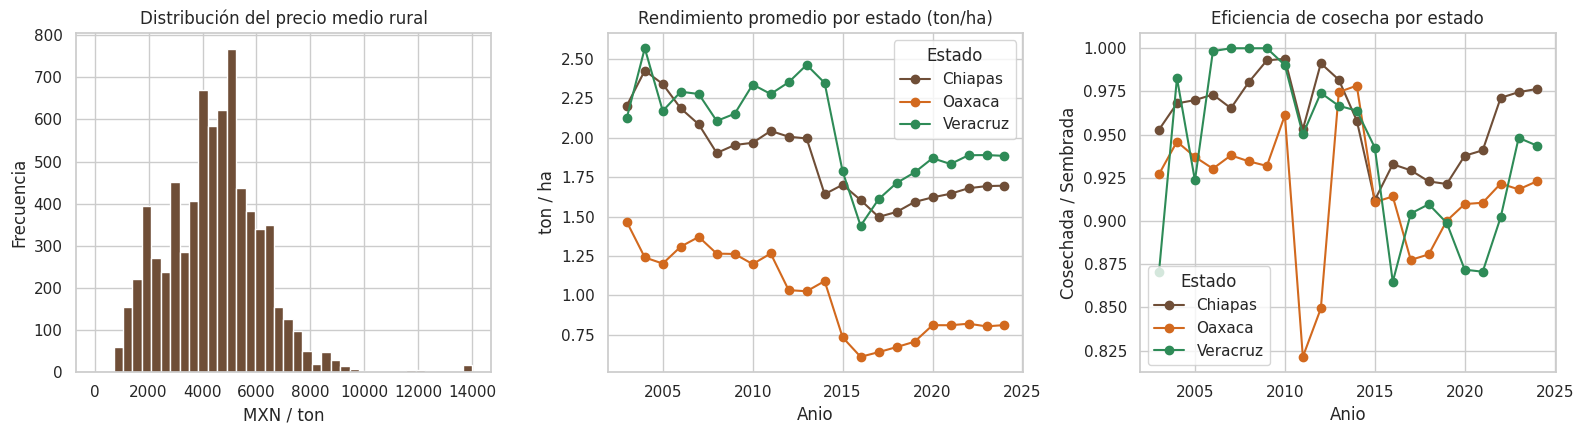

In [ ]:
# ── Gráficas adicionales del EDA ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Histograma de precios
df_hist = siap.filter(F.col('Precio_medio_rural') > 0).select('Precio_medio_rural').toPandas()
axes[0].hist(df_hist['Precio_medio_rural'], bins=40, color=PALETA['productor'], edgecolor='white')
axes[0].set_title("Distribución del precio medio rural")
axes[0].set_xlabel("MXN / ton"); axes[0].set_ylabel("Frecuencia")

# (2) Rendimiento promedio por estado y año
df_rend = (siap.groupBy('Anio','Estado').agg(F.mean('Rendimiento').alias('rend'))
               .toPandas().pivot(index='Anio', columns='Estado', values='rend'))
df_rend.plot(ax=axes[1], marker='o',
             color=[PALETA['productor'], PALETA['acento'], PALETA['consumidor']])
axes[1].set_title("Rendimiento promedio por estado (ton/ha)")
axes[1].set_ylabel("ton / ha")

# (3) Eficiencia promedio por estado y año
df_eff = (siap.withColumn('eff', F.when(F.col('Sup_sembrada')>0,
              F.col('Sup_cosechada')/F.col('Sup_sembrada')).otherwise(0))
              .groupBy('Anio','Estado').agg(F.mean('eff').alias('eff'))
              .toPandas().pivot(index='Anio', columns='Estado', values='eff'))
df_eff.plot(ax=axes[2], marker='o',
            color=[PALETA['productor'], PALETA['acento'], PALETA['consumidor']])
axes[2].set_title("Eficiencia de cosecha por estado")
axes[2].set_ylabel("Cosechada / Sembrada")

plt.tight_layout(); plt.show()

### 1.3 — Limpieza con Spark

In [ ]:
# ── 1) Imputar precios en cero ─────────────────────────────────────────────
mediana_muni = (siap.filter(F.col('Precio_medio_rural') > 0)
                    .groupBy('Municipio','Anio')
                    .agg(F.expr('percentile_approx(Precio_medio_rural, 0.5)').alias('med_muni')))
mediana_anio = (siap.filter(F.col('Precio_medio_rural') > 0)
                    .groupBy('Anio')
                    .agg(F.expr('percentile_approx(Precio_medio_rural, 0.5)').alias('med_anio')))

siap_clean = (siap.join(mediana_muni, on=['Municipio','Anio'], how='left')
                  .join(mediana_anio, on='Anio', how='left'))
siap_clean = siap_clean.withColumn(
    'Precio_medio_rural',
    F.when(F.col('Precio_medio_rural') == 0,
           F.coalesce(F.col('med_muni'), F.col('med_anio')))
     .otherwise(F.col('Precio_medio_rural'))
).drop('med_muni','med_anio')

med_global = (siap_clean.filter(F.col('Precio_medio_rural').isNotNull())
                        .agg(F.expr('percentile_approx(Precio_medio_rural, 0.5)')).collect()[0][0])
siap_clean = siap_clean.fillna({'Precio_medio_rural': med_global})
print(f"Ceros restantes: {siap_clean.filter(F.col('Precio_medio_rural')==0).count()}")

# ── 2) Estandarizar municipios ────────────────────────────────────────────
siap_clean = siap_clean.withColumn(
    'Municipio', F.initcap(F.regexp_replace(F.trim(F.col('Municipio')), r'\s+', ' ')))

# ── 3) Validar cosechada ≤ sembrada ───────────────────────────────────────
siap_clean = siap_clean.withColumn(
    'Sup_cosechada',
    F.when(F.col('Sup_cosechada') > F.col('Sup_sembrada'), F.col('Sup_sembrada'))
     .otherwise(F.col('Sup_cosechada')))
print("Limpieza completada ✓")

Ceros restantes: 0
Limpieza completada ✓


### 1.4 — Feature engineering

In [ ]:
siap_clean = (siap_clean
    .withColumn('precio_per_kg', F.col('Precio_medio_rural') / 1000.0)
    .withColumn('eficiencia',
        F.when(F.col('Sup_sembrada') > 0,
               F.least(F.col('Sup_cosechada') / F.col('Sup_sembrada'), F.lit(1.0)))
         .otherwise(F.lit(0.0)))
    .withColumn('valor_por_ha',
        F.when(F.col('Sup_sembrada') > 0,
               F.col('Valor_produccion') / F.col('Sup_sembrada'))
         .otherwise(F.lit(0.0)))
)
siap_clean.select('Estado','Municipio','Anio','precio_per_kg','eficiencia','valor_por_ha').show(5)

+-------+--------------------+----+------------------+----------+------------------+
| Estado|           Municipio|Anio|     precio_per_kg|eficiencia|      valor_por_ha|
+-------+--------------------+----+------------------+----------+------------------+
|Chiapas|          Altamirano|2003|             1.642|       1.0|4.4169795692987295|
|Chiapas|          Acapetahua|2003|               3.7|       1.0| 9.730952380952381|
|Chiapas|  Angel Albino Corzo|2003|2.2626999999999997|       1.0|1.8214740000000003|
|Chiapas|              Amatán|2003|               2.0|       1.0|3.5299722111949188|
|Chiapas|Amatenango De La ...|2003|           2.26543|       1.0|  8.49536339589369|
+-------+--------------------+----+------------------+----------+------------------+
only showing top 5 rows


### 1.5 — Conversión a pandas y brecha de precios

In [ ]:
# ── Convertir Spark → pandas ───────────────────────────────────────────────
siap = siap_clean.toPandas()
precios = precios_spark.orderBy('Date').toPandas().set_index('Date')
precios.index = pd.to_datetime(precios.index)
print(f"SIAP pandas: {siap.shape} | Precios pandas: {precios.shape}")

SIAP pandas: (7269, 16) | Precios pandas: (5637, 2)


In [ ]:
# ── Brecha productor vs futuros ─────────────────────────────────────────────
LB_A_KG = 0.453592
FACTOR_CEREZA_VERDE = 5.5
precios['kc_mxn_kg'] = precios['kc_usd_lb'] * precios['usdmxn'] / LB_A_KG

futuros_anual = precios['kc_mxn_kg'].resample('YE').mean()
futuros_anual.index = futuros_anual.index.year
productor_anual = siap.groupby('Anio')['precio_per_kg'].mean().rename('productor_mxn_kg')

brecha = pd.concat([productor_anual, futuros_anual.rename('futuros_mxn_kg')], axis=1).dropna()
brecha['productor_equiv_verde'] = brecha['productor_mxn_kg'] * FACTOR_CEREZA_VERDE
brecha['brecha_ajustada_pct'] = ((brecha['futuros_mxn_kg'] - brecha['productor_equiv_verde'])
                                  / brecha['futuros_mxn_kg'] * 100)
display(brecha.tail(8).round(2))

ult = brecha.index.max()
print(f"\nEn {ult}: productor recibe ~{100 - brecha.loc[ult,'brecha_ajustada_pct']:.0f}% "
      f"del precio internacional")

,productor_mxn_kg,futuros_mxn_kg,productor_equiv_verde,brecha_ajustada_pct
2017,5.24,55.47,28.84,48.00
2018,5.26,47.72,28.93,39.37
2019,5.05,42.92,27.79,35.26
2020,5.26,52.62,28.95,44.98
2021,5.42,75.68,29.83,60.58
2022,6.12,95.25,33.65,64.67
2023,6.41,67.45,35.26,47.73
2024,6.17,96.06,33.91,64.70



En 2024: productor recibe ~35% del precio internacional


In [ ]:
# ── Gráfico interactivo de la brecha ───────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=brecha.index, y=brecha['productor_mxn_kg'],
    mode='lines+markers', name='Productor — cereza',
    line=dict(color=PALETA['productor'], width=2.5)))
fig.add_trace(go.Scatter(x=brecha.index, y=brecha['productor_equiv_verde'],
    mode='lines+markers', name='Productor — equiv. verde (×5.5)',
    line=dict(color=PALETA['acento'], width=2, dash='dash')))
fig.add_trace(go.Scatter(x=brecha.index, y=brecha['futuros_mxn_kg'],
    mode='lines+markers', name='ICE Futures KC=F (verde)',
    line=dict(color=PALETA['futuros'], width=2.5)))
fig.update_layout(title="Brecha de precios — productor vs. mercado internacional (MXN/kg)",
    xaxis_title="Año", yaxis_title="MXN / kg",
    template="plotly_white", height=480, hovermode='x unified')
fig.show()

## Sección 2 — Pronóstico con ARIMA
**Materia:** Modelos Estocásticos para la Toma de Decisiones


### 2.1 — Serie mensual y descomposición

Serie mensual: 270 obs, 2003-12-01 → 2026-05-01


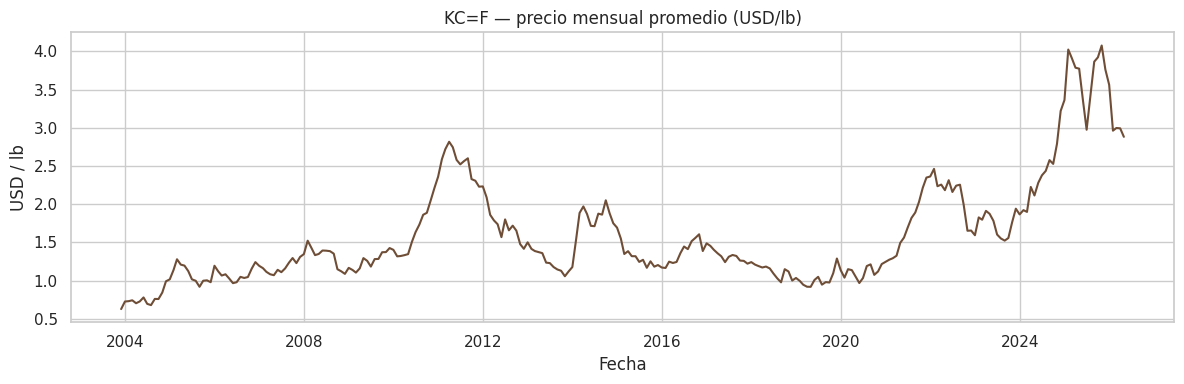

In [ ]:
mensual = precios['kc_usd_lb'].resample('MS').mean().dropna()
print(f"Serie mensual: {len(mensual)} obs, {mensual.index.min().date()} → {mensual.index.max().date()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mensual.index, mensual.values, color=PALETA['productor'], linewidth=1.5)
ax.set_title("KC=F — precio mensual promedio (USD/lb)")
ax.set_xlabel("Fecha"); ax.set_ylabel("USD / lb")
plt.tight_layout(); plt.show()

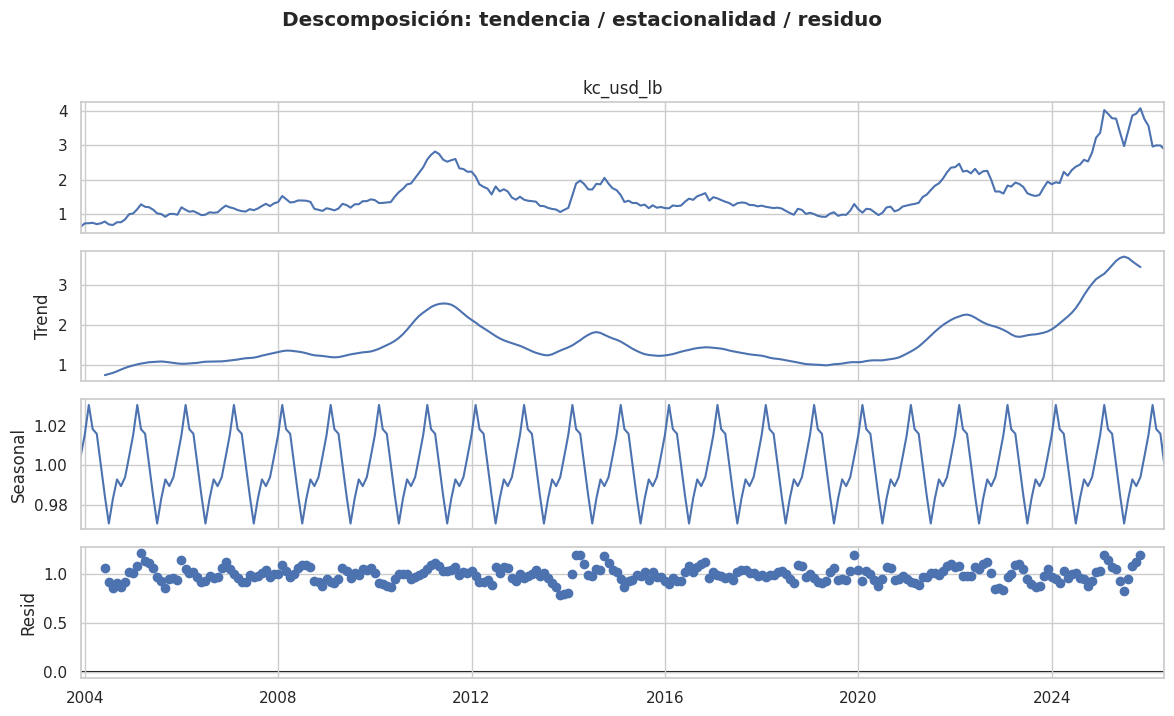

In [ ]:
# ── Descomposición estacional ──────────────────────────────────────────────
descomp = seasonal_decompose(mensual, model='multiplicative', period=12)
fig = descomp.plot(); fig.set_size_inches(12, 7)
fig.suptitle("Descomposición: tendencia / estacionalidad / residuo", y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.2 — Prueba de estacionariedad

In [ ]:
def prueba_adf(serie, etiqueta):
    stat, p, *_ = adfuller(serie.dropna())
    print(f"  {etiqueta:25s} ADF={stat:7.3f}  p={p:.4f}  → {'estacionaria' if p<0.05 else 'NO estacionaria'}")

print("Pruebas ADF:")
prueba_adf(mensual, "Nivel original")
prueba_adf(np.log(mensual), "Logaritmo")
prueba_adf(np.log(mensual).diff(), "Primera dif. log")

Pruebas ADF:
  Nivel original            ADF= -3.108  p=0.0259  → estacionaria
  Logaritmo                 ADF= -1.886  p=0.3389  → NO estacionaria
  Primera dif. log          ADF=-14.026  p=0.0000  → estacionaria


### 2.3 — Entrenamiento y evaluación de ARIMA

In [ ]:
# ── Split 80/20 cronológico ────────────────────────────────────────────────
corte = int(len(mensual) * 0.8)
train, test = mensual.iloc[:corte], mensual.iloc[corte:]
print(f"Train: {len(train)} meses | Test: {len(test)} meses")

# ── Auto-ARIMA ────────────────────────────────────────────────────────────
modelo_arima = pm.auto_arima(train, seasonal=True, m=12,
    start_p=0, start_q=0, max_p=4, max_q=4, d=None, D=1,
    error_action='ignore', suppress_warnings=True, stepwise=True)
pred_arima = np.asarray(modelo_arima.predict(n_periods=len(test)))
print(f"Modelo: ARIMA{modelo_arima.order} × {modelo_arima.seasonal_order}")

# ── Métricas ──────────────────────────────────────────────────────────────
mae = mean_absolute_error(test, pred_arima)
rmse = np.sqrt(mean_squared_error(test, pred_arima))
mape = np.mean(np.abs((test.values - pred_arima) / test.values)) * 100
print(f"\nMAE  = {mae:.4f} USD/lb")
print(f"RMSE = {rmse:.4f} USD/lb")
print(f"MAPE = {mape:.2f} %")

Train: 216 meses | Test: 54 meses
Modelo: ARIMA(2, 0, 1) × (2, 1, 0, 12)

MAE  = 0.7822 USD/lb
RMSE = 1.0894 USD/lb
MAPE = 25.76 %


In [ ]:
# ── Gráfico: ARIMA backtest ────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train.values, mode='lines',
    name='Entrenamiento', line=dict(color=PALETA['neutro'], width=1.5), opacity=0.6))
fig.add_trace(go.Scatter(x=test.index, y=test.values, mode='lines',
    name='Prueba (real)', line=dict(color=PALETA['productor'], width=2.5)))
fig.add_trace(go.Scatter(x=test.index, y=pred_arima, mode='lines',
    name='ARIMA', line=dict(color=PALETA['acento'], width=2, dash='dash')))
fig.update_layout(title="ARIMA — backtest sobre el conjunto de prueba",
    xaxis_title="Fecha", yaxis_title="USD / lb",
    template="plotly_white", height=440, hovermode='x unified')
fig.show()

### 2.4 — Pronósticos a 3, 6 y 12 meses

In [ ]:
# ── Reentrenar con todos los datos ─────────────────────────────────────────
modelo_final = pm.auto_arima(mensual, seasonal=True, m=12,
    start_p=0, start_q=0, max_p=4, max_q=4, d=None, D=1,
    error_action='ignore', suppress_warnings=True, stepwise=True)

horizontes = {'3 meses': 3, '6 meses': 6, '12 meses': 12}
pronosticos = {}
for etiq, h in horizontes.items():
    pt, ci = modelo_final.predict(n_periods=h, return_conf_int=True)
    pt = np.asarray(pt)
    idx = pd.date_range(mensual.index[-1] + pd.DateOffset(months=1), periods=h, freq='MS')
    pronosticos[etiq] = pd.DataFrame({'punto': pt, 'inf': ci[:,0], 'sup': ci[:,1]}, index=idx)
    print(f"{etiq}: {pt[-1]:.2f} USD/lb  IC=[{ci[-1,0]:.2f}, {ci[-1,1]:.2f}]")

3 meses: 2.86 USD/lb  IC=[2.34, 3.38]
6 meses: 2.85 USD/lb  IC=[2.09, 3.60]
12 meses: 3.10 USD/lb  IC=[2.05, 4.15]


In [ ]:
# ── Gráfico de pronósticos con IC ─────────────────────────────────────────
fig = go.Figure()
hist = mensual.tail(48)
fig.add_trace(go.Scatter(x=hist.index, y=hist.values, mode='lines',
    name='Histórico (4 años)', line=dict(color=PALETA['productor'], width=2.5)))
colores = [PALETA['acento'], PALETA['consumidor'], PALETA['futuros']]
for (etiq, df_p), col in zip(pronosticos.items(), colores):
    fig.add_trace(go.Scatter(
        x=list(df_p.index)+list(df_p.index[::-1]),
        y=list(df_p['sup'])+list(df_p['inf'][::-1]),
        fill='toself', fillcolor='rgba(210,105,30,0.10)',
        line=dict(color='rgba(255,255,255,0)'), showlegend=False, hoverinfo='skip'))
    fig.add_trace(go.Scatter(x=df_p.index, y=df_p['punto'],
        mode='lines+markers', name=f'Pronóstico {etiq}', line=dict(color=col, width=2)))
fig.update_layout(title="Pronósticos ARIMA (IC 95%)",
    xaxis_title="Fecha", yaxis_title="USD / lb",
    template="plotly_white", height=480, hovermode='x unified')
fig.show()

## Sección 3 — Clasificación con Random Forest
**Materia:** Aprendizaje Máquina

**Objetivo:** predecir si el precio del próximo mes estará **por encima o por
debajo** de su media móvil de 252 días. Es una señal de tendencia útil para
el productor: si el modelo predice "ALZA", conviene esperar; si predice
"BAJA", puede ser buen momento para vender antes del retroceso.


### 3.1 — Construir la matriz de variables

In [ ]:
# ── Target: ¿el precio está arriba de su media de 252 días? ──────────────
df = precios.copy()
df['ma252']  = df['kc_usd_lb'].rolling(252).mean()
df['target'] = (df['kc_usd_lb'] > df['ma252']).astype(int)

# ── Features de precio ────────────────────────────────────────────────────
for lag in [1, 7, 30]:
    df[f'lag_{lag}']  = df['kc_usd_lb'].shift(lag)
    df[f'ret_{lag}']  = df['kc_usd_lb'].pct_change(lag)

# ── Volatilidad a 30 días ─────────────────────────────────────────────────
df['vol_30'] = df['kc_usd_lb'].pct_change().rolling(30).std()

# ── Variables de calendario ───────────────────────────────────────────────
df['mes']       = df.index.month
df['trimestre'] = df.index.quarter

# ── Limpiar filas con NaN (por los lags y la media móvil) ────────────────
df = df.dropna()
print(f"Matriz de features: {df.shape}")
print(f"Balance del target: {df['target'].value_counts().to_dict()}")

Matriz de features: (5386, 14)
Balance del target: {1: 2864, 0: 2522}


### 3.2 — Entrenamiento del modelo

In [ ]:
# ── Separar features y target ─────────────────────────────────────────────
DROP = ['target', 'kc_usd_lb', 'ma252', 'kc_mxn_kg']
features = [c for c in df.columns if c not in DROP]
X, y = df[features], df['target']

# ── Split cronológico 80/20 ──────────────────────────────────────────────
corte_rf = int(len(df) * 0.80)
X_tr, X_te = X.iloc[:corte_rf], X.iloc[corte_rf:]
y_tr, y_te = y.iloc[:corte_rf], y.iloc[corte_rf:]
print(f"Train: {len(X_tr)} días | Test: {len(X_te)} días")

# ── Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,    # 300 árboles — suficiente para estabilizar
    max_depth=8,         # profundidad limitada para evitar sobreajuste
    random_state=42,
    n_jobs=-1,           # usar todos los cores disponibles
)
rf.fit(X_tr, y_tr)
print(f"\nAccuracy train: {rf.score(X_tr, y_tr):.3f}")
print(f"Accuracy test:  {rf.score(X_te, y_te):.3f}")

Train: 4308 días | Test: 1078 días

Accuracy train: 0.950
Accuracy test:  0.673


### 3.3 — Evaluación del modelo

In [ ]:
# ── Predicciones ──────────────────────────────────────────────────────────
y_pred  = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]
print(classification_report(y_te, y_pred, target_names=['Baja', 'Alza']))

              precision    recall  f1-score   support

        Baja       0.70      0.35      0.47       441
        Alza       0.67      0.89      0.76       637

    accuracy                           0.67      1078
   macro avg       0.68      0.62      0.62      1078
weighted avg       0.68      0.67      0.64      1078



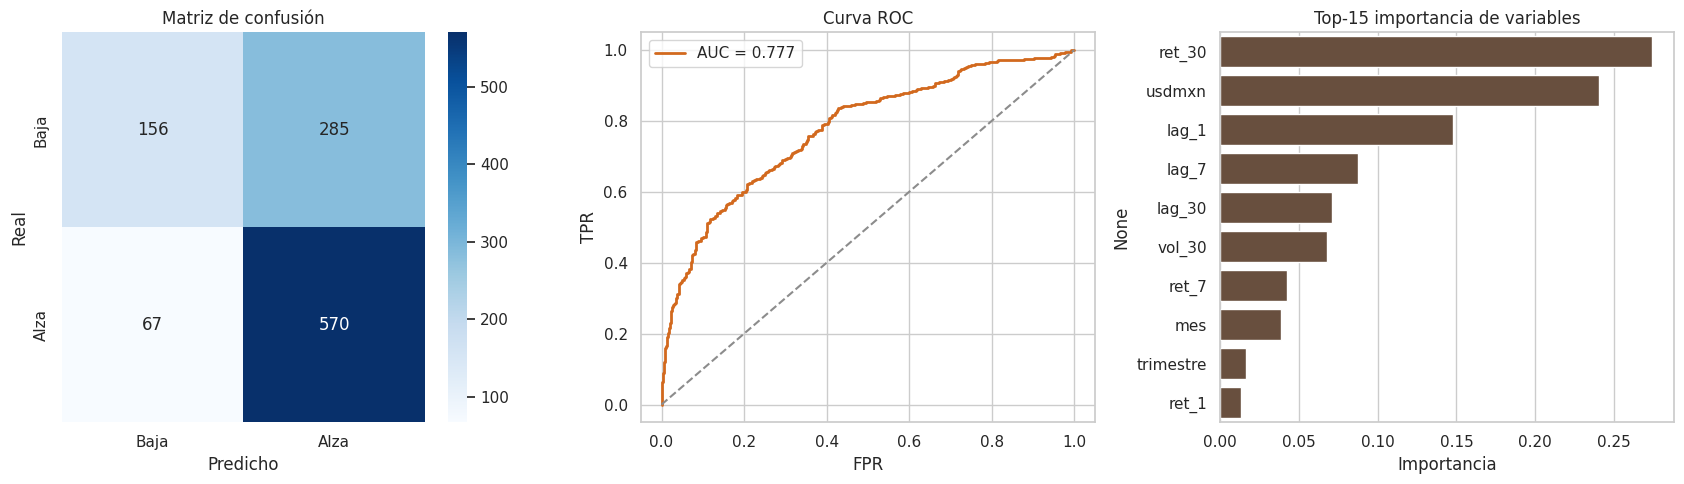

In [ ]:
# ── Tres gráficas de evaluación ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (1) Matriz de confusión
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja','Alza'], yticklabels=['Baja','Alza'], ax=axes[0])
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

# (2) Curva ROC
fpr, tpr, _ = roc_curve(y_te, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=PALETA['acento'], linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], '--', color=PALETA['neutro'])
axes[1].set_title("Curva ROC"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend()

# (3) Top-15 importancia de variables
imp = pd.Series(rf.feature_importances_, index=features).nlargest(15)
sns.barplot(x=imp.values, y=imp.index, ax=axes[2], color=PALETA['productor'])
axes[2].set_title("Top-15 importancia de variables")
axes[2].set_xlabel("Importancia")

plt.tight_layout(); plt.show()

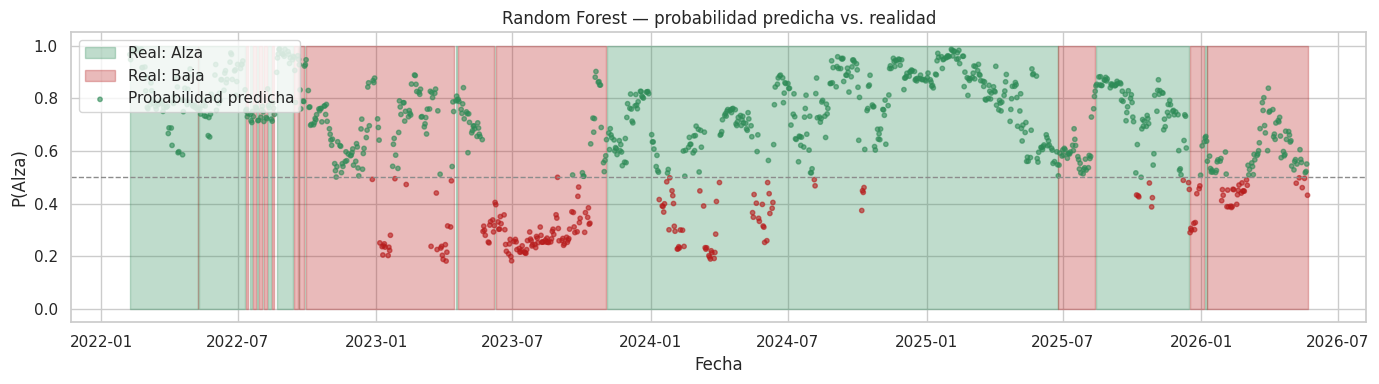

In [ ]:
# ── Gráfica adicional: predicciones vs realidad en el tiempo ──────────────
fig, ax = plt.subplots(figsize=(14, 4))
fechas_test = X_te.index
ax.fill_between(fechas_test, 0, 1, where=(y_te==1), alpha=0.3,
                color=PALETA['consumidor'], label='Real: Alza')
ax.fill_between(fechas_test, 0, 1, where=(y_te==0), alpha=0.3,
                color='#B71C1C', label='Real: Baja')
ax.scatter(fechas_test, y_proba, c=[PALETA['consumidor'] if p>0.5 else '#B71C1C' for p in y_proba],
           s=10, alpha=0.6, label='Probabilidad predicha')
ax.axhline(0.5, color=PALETA['neutro'], linestyle='--', linewidth=1)
ax.set_title("Random Forest — probabilidad predicha vs. realidad")
ax.set_xlabel("Fecha"); ax.set_ylabel("P(Alza)")
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

## Sección 4 — Optimización del cultivo (Programación Lineal)
**Materia:** Investigación de Operaciones


In [ ]:
TIPOS  = ['cereza', 'lavado', 'organico']
PRECIO = {'cereza': 22, 'lavado': 45, 'organico': 75}
RENDIM = {'cereza': 2_500, 'lavado': 1_800, 'organico': 1_200}
COSTO  = {'cereza': 18_000, 'lavado': 35_000, 'organico': 55_000}
MAX_HA, MAX_PRES, MAX_ALM = 50, 1_500_000, 90_000

def resolver_pl(pd_):
    prob = pulp.LpProblem("MJ", pulp.LpMaximize)
    x = {t: pulp.LpVariable(f"ha_{t}", lowBound=0) for t in TIPOS}
    prob += pulp.lpSum(pd_[t]*RENDIM[t]*x[t] for t in TIPOS)
    prob += pulp.lpSum(x[t] for t in TIPOS) <= MAX_HA
    prob += pulp.lpSum(COSTO[t]*x[t] for t in TIPOS) <= MAX_PRES
    prob += pulp.lpSum(RENDIM[t]*x[t] for t in TIPOS) <= MAX_ALM
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    return {t: x[t].value() for t in TIPOS}, pulp.value(prob.objective)

plan, ing = resolver_pl(PRECIO)
print("Plan óptimo:")
for t in TIPOS:
    print(f"  {t:12s} {plan[t]:6.2f} ha  →  {plan[t]*RENDIM[t]:8,.0f} kg  →  MXN {plan[t]*RENDIM[t]*PRECIO[t]:>10,.0f}")
print(f"\nIngreso total: MXN {ing:,.0f}")

Plan óptimo:
  cereza         8.17 ha  →    20,417 kg  →  MXN    449,183
  lavado        38.66 ha  →    69,583 kg  →  MXN  3,131,216
  organico       0.00 ha  →         0 kg  →  MXN          0

Ingreso total: MXN 3,580,399


In [ ]:
# ── Sensibilidad ──────────────────────────────────────────────────────────
shocks = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
recs = []
for s in shocks:
    p = {t: PRECIO[t]*(1+s) for t in TIPOS}
    pl, ingr = resolver_pl(p)
    r = {'shock': int(s*100), 'ingreso': ingr}
    for t in TIPOS: r[f'ha_{t}'] = pl[t]
    recs.append(r)
sens = pd.DataFrame(recs)
display(sens.round(2))

,shock,ingreso,ha_cereza,ha_lavado,ha_organico
0,-30,2506279.47,8.17,38.66,0.0
1,-20,2864319.40,8.17,38.66,0.0
2,-10,3222359.32,8.17,38.66,0.0
3,0,3580399.25,8.17,38.66,0.0
4,10,3938439.17,8.17,38.66,0.0
5,20,4296479.10,8.17,38.66,0.0
6,30,4654519.02,8.17,38.66,0.0


In [ ]:
# ── Visualización de sensibilidad ─────────────────────────────────────────
fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Ingreso por escenario", "Plan de hectáreas"))
cols = ['#B71C1C' if s<0 else PALETA['neutro'] if s==0 else PALETA['consumidor']
        for s in sens['shock']]
fig.add_trace(go.Bar(x=sens['shock'].astype(str)+'%', y=sens['ingreso']/1e6,
    marker_color=cols, text=[f"{v/1e6:.2f}M" for v in sens['ingreso']],
    textposition='outside', showlegend=False), row=1, col=1)
for t, c in zip(TIPOS, [PALETA['productor'], PALETA['acento'], PALETA['consumidor']]):
    fig.add_trace(go.Bar(x=sens['shock'].astype(str)+'%', y=sens[f'ha_{t}'],
        name=t, marker_color=c), row=1, col=2)
fig.update_yaxes(title_text="Millones MXN", row=1, col=1)
fig.update_yaxes(title_text="Hectáreas", row=1, col=2)
fig.update_layout(barmode='stack', template="plotly_white", height=440,
    title_text="Análisis de sensibilidad")
fig.show()

## Sección 5 — Dashboard interactivo
**Materia:** Mercadotecnia Digital


### 5.1 — Precio histórico con bandas de Bollinger

In [ ]:
pf = precios[['kc_usd_lb']].copy()
pf['media'] = pf['kc_usd_lb'].rolling(252).mean()
pf['up'] = pf['media'] + 2*pf['kc_usd_lb'].rolling(252).std()
pf['dn'] = pf['media'] - 2*pf['kc_usd_lb'].rolling(252).std()
pf = pf.dropna()
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=pf.index, y=pf['up'], line=dict(width=0), showlegend=False))
fig1.add_trace(go.Scatter(x=pf.index, y=pf['dn'], line=dict(width=0),
    fill='tonexty', fillcolor='rgba(194,154,107,0.20)', name='Banda ±2σ'))
fig1.add_trace(go.Scatter(x=pf.index, y=pf['kc_usd_lb'],
    line=dict(color=PALETA['productor'], width=1.5), name='Cierre KC=F'))
fig1.add_trace(go.Scatter(x=pf.index, y=pf['media'],
    line=dict(color=PALETA['acento'], dash='dash', width=2), name='Media 252d'))
fig1.update_layout(title="KC=F — precio, media móvil y banda ±2σ",
    xaxis_title="Fecha", yaxis_title="USD/lb",
    template="plotly_white", height=440, hovermode='x unified')
fig1.show()

### 5.2 — Cadena de valor

In [ ]:
u = int(brecha.index.max())
p_cer = float(brecha.loc[u,'productor_mxn_kg'])
p_ver = float(brecha.loc[u,'productor_equiv_verde'])
p_fut = float(brecha.loc[u,'futuros_mxn_kg'])
p_ret = p_fut * 3.5
cad = pd.DataFrame({
    "etapa": ["Productor\n(cereza)","Productor\n(equiv. verde)","ICE Futures\n(verde)","Consumidor\n(retail)"],
    "precio": [p_cer, p_ver, p_fut, p_ret]})
fig2 = px.bar(cad, x="etapa", y="precio", text=cad['precio'].round(1), color="etapa",
    color_discrete_sequence=[PALETA['productor'],PALETA['acento'],PALETA['futuros'],PALETA['consumidor']],
    labels={"precio":"MXN/kg","etapa":""}, title=f"Cadena de valor del café — {u} (MXN/kg)")
fig2.update_traces(textposition='outside')
fig2.update_layout(template="plotly_white", showlegend=False, height=480)
fig2.show()

### 5.3 — Heatmap estacional

In [ ]:
heat = (precios['kc_usd_lb'].resample('MS').mean().to_frame('p')
    .assign(anio=lambda d: d.index.year, mes=lambda d: d.index.month)
    .pivot_table(index='anio', columns='mes', values='p'))
fig3 = px.imshow(heat, color_continuous_scale='Oranges', aspect='auto',
    labels=dict(x="Mes", y="Año", color="USD/lb"),
    title="Heatmap estacional — precio mensual promedio KC=F")
fig3.update_layout(template="plotly_white", height=520)
fig3.show()

### 5.4 — Evolución del tipo de cambio

In [ ]:
fig_fx = go.Figure()
fx_mensual = precios['usdmxn'].resample('MS').mean()
fig_fx.add_trace(go.Scatter(x=fx_mensual.index, y=fx_mensual.values,
    mode='lines', name='USD/MXN', line=dict(color=PALETA['consumidor'], width=2)))
fig_fx.update_layout(title="Tipo de cambio USD/MXN (promedio mensual)",
    xaxis_title="Fecha", yaxis_title="MXN por USD",
    template="plotly_white", height=380, hovermode='x unified')
fig_fx.show()

### 5.5 — Panel de recomendación

In [ ]:
precio_actual = float(precios['kc_usd_lb'].iloc[-1])
media_larga   = float(precios['kc_usd_lb'].rolling(252).mean().iloc[-1])
pron_3m  = float(pronosticos['3 meses']['punto'].iloc[-1])
pron_6m  = float(pronosticos['6 meses']['punto'].iloc[-1])
pron_12m = float(pronosticos['12 meses']['punto'].iloc[-1])
brecha_act = float(brecha['brecha_ajustada_pct'].iloc[-1])

# Señal del Random Forest
ml_proba = float(rf.predict_proba(X.iloc[[-1]])[0, 1])
ml_senal = "ALZA" if ml_proba > 0.5 else "BAJA"

arriba = precio_actual > media_larga
baja   = pron_3m < precio_actual

if arriba and baja:
    accion = "VENDER"
    razon = "Precio arriba de la media y pronóstico a la baja."
elif arriba and not baja:
    accion = "MANTENER"
    razon = "Tendencia alcista vigente."
else:
    accion = "MANTENER"
    razon = "Precio bajo la media, mejor esperar."

print("=" * 60)
print("     RESUMEN PARA EL PRODUCTOR — Mercado Justo")
print("=" * 60)
print(f"  Precio actual ........... {precio_actual:.2f} USD/lb")
print(f"  Media 252 días .......... {media_larga:.2f} USD/lb")
print(f"  Pronóstico 3m ........... {pron_3m:.2f} USD/lb")
print(f"  Pronóstico 6m ........... {pron_6m:.2f} USD/lb")
print(f"  Pronóstico 12m .......... {pron_12m:.2f} USD/lb")
print(f"  Señal ML (P alza) ....... {ml_proba:.1%} → {ml_senal}")
print(f"  Brecha ajustada ......... {brecha_act:.1f}%")
print(f"  ACCIÓN: {accion} — {razon}")
print("=" * 60)

     RESUMEN PARA EL PRODUCTOR — Mercado Justo
  Precio actual ........... 2.64 USD/lb
  Media 252 días .......... 3.41 USD/lb
  Pronóstico 3m ........... 2.86 USD/lb
  Pronóstico 6m ........... 2.85 USD/lb
  Pronóstico 12m .......... 3.10 USD/lb
  Señal ML (P alza) ....... 43.2% → BAJA
  Brecha ajustada ......... 64.7%
  ACCIÓN: MANTENER — Precio bajo la media, mejor esperar.


In [ ]:
# ── Panel visual de indicadores ────────────────────────────────────────────
fig5 = make_subplots(rows=2, cols=4,
    specs=[[{"type":"indicator"}]*4, [{"type":"indicator"}]*4],
    subplot_titles=("Precio actual","Pronóstico 3m","Pronóstico 6m","Pronóstico 12m",
                    "Acción","Señal ML (P alza)","Brecha ajustada",""))
fig5.add_trace(go.Indicator(mode="number", value=precio_actual,
    number=dict(suffix=" USD/lb", valueformat=".2f")), row=1, col=1)
fig5.add_trace(go.Indicator(mode="number+delta", value=pron_3m,
    number=dict(suffix=" USD/lb", valueformat=".2f"),
    delta=dict(reference=precio_actual, relative=True, valueformat=".1%")), row=1, col=2)
fig5.add_trace(go.Indicator(mode="number+delta", value=pron_6m,
    number=dict(suffix=" USD/lb", valueformat=".2f"),
    delta=dict(reference=precio_actual, relative=True, valueformat=".1%")), row=1, col=3)
fig5.add_trace(go.Indicator(mode="number+delta", value=pron_12m,
    number=dict(suffix=" USD/lb", valueformat=".2f"),
    delta=dict(reference=precio_actual, relative=True, valueformat=".1%")), row=1, col=4)
fig5.add_trace(go.Indicator(mode="number", value=1 if accion=="VENDER" else 0,
    number=dict(prefix=accion, valueformat=" ")), row=2, col=1)
fig5.add_trace(go.Indicator(mode="gauge+number", value=ml_proba*100,
    number=dict(suffix="%"), gauge=dict(axis=dict(range=[0,100]),
    bar=dict(color=PALETA['acento']))), row=2, col=2)
fig5.add_trace(go.Indicator(mode="gauge+number", value=brecha_act,
    number=dict(suffix="%", valueformat=".1f"),
    gauge=dict(axis=dict(range=[0,100]),
    bar=dict(color=PALETA['productor']))), row=2, col=3)
fig5.update_layout(template="plotly_white", height=540,
    title_text="Mercado Justo — panel de recomendación")
fig5.show()

## Sección 6 — Arquitectura Big Data
**Materia:** Herramientas para el Almacenamiento de Grandes Volúmenes

En la Sección 1 implementamos el ETL con PySpark en modo local. El mismo
código funcionaría sobre un clúster distribuido si el volumen creciera.

```
FUENTES (SNIIM, SIAP, FIRA, CONAGUA, INEGI)
    │
    ▼
INGESTA → Apache NiFi → HDFS
    │
    ▼
PROCESAMIENTO → Spark batch + Kafka streaming
    │
    ▼
ANÁLISIS → Hive/Impala + Spark MLlib + API REST + Dashboard
```


## Sección 7 — Exportar datos para el bot de Telegram

Esta sección genera los 5 archivos que necesita el bot de Telegram para
funcionar. Después de ejecutar estas celdas, descarga los archivos de la
carpeta `bot_data/` y cópialos a tu servidor.

Los archivos se guardan en una carpeta relativa para que funcione tanto en
Google Colab como en Jupyter local (Linux).


In [ ]:
# ── Crear carpeta de exportación ──────────────────────────────────────────
import os, json, joblib

EXPORT_DIR = 'bot_data'
os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(f'{EXPORT_DIR}/modelos', exist_ok=True)
os.makedirs(f'{EXPORT_DIR}/datos', exist_ok=True)

print(f"Carpeta de exportación: {os.path.abspath(EXPORT_DIR)}")

# ── 1) Guardar modelo ARIMA ──────────────────────────────────────────────
joblib.dump(modelo_final, f'{EXPORT_DIR}/modelos/arima_model.pkl')
print(f"✓ arima_model.pkl guardado (ARIMA{modelo_final.order}×{modelo_final.seasonal_order})")

# ── 2) Guardar modelo Random Forest ──────────────────────────────────────
joblib.dump(rf, f'{EXPORT_DIR}/modelos/rf_model.pkl')
print(f"✓ rf_model.pkl guardado ({rf.n_estimators} árboles, max_depth={rf.max_depth})")

# ── 3) Guardar lista de features del Random Forest ───────────────────────
# El bot necesita saber qué columnas alimentar al modelo y en qué orden.
with open(f'{EXPORT_DIR}/modelos/rf_features.json', 'w') as f:
    json.dump(features, f, indent=2)
print(f"✓ rf_features.json guardado ({len(features)} features)")

# ── 4) Guardar tabla de brecha histórica ─────────────────────────────────
brecha.to_csv(f'{EXPORT_DIR}/datos/brecha.csv')
print(f"✓ brecha.csv guardado ({len(brecha)} años)")

# ── 5) Guardar rendimientos por estado y municipio ───────────────────────
# Promedio de los últimos 5 años para que sea representativo del presente.
ultimos_5 = siap[siap['Anio'] >= siap['Anio'].max() - 4]

# Por estado
rend_estado = (ultimos_5.groupby('Estado')
    .agg(
        rendimiento_ton_ha=('Rendimiento', 'mean'),
        precio_mxn_ton=('Precio_medio_rural', 'mean'),
        precio_mxn_kg=('precio_per_kg', 'mean'),
        eficiencia=('eficiencia', 'mean'),
        produccion_total=('Produccion', 'sum'),
        hectareas_promedio=('Sup_sembrada', 'mean'),
    ).round(4))
rend_estado.to_csv(f'{EXPORT_DIR}/datos/rendimientos_estado.csv')
print(f"✓ rendimientos_estado.csv guardado ({len(rend_estado)} estados)")

# Por municipio
rend_muni = (ultimos_5.groupby(['Estado', 'Municipio'])
    .agg(
        rendimiento_ton_ha=('Rendimiento', 'mean'),
        precio_mxn_ton=('Precio_medio_rural', 'mean'),
        precio_mxn_kg=('precio_per_kg', 'mean'),
        eficiencia=('eficiencia', 'mean'),
        produccion_total=('Produccion', 'sum'),
    ).round(4))
rend_muni.to_csv(f'{EXPORT_DIR}/datos/rendimientos_municipio.csv')
print(f"✓ rendimientos_municipio.csv guardado ({len(rend_muni)} municipios)")

# ── 6) Guardar plan óptimo de PuLP ───────────────────────────────────────
plan_data = {
    'plan_hectareas': plan,
    'ingreso_total': ing,
    'parametros': {
        'precios_mxn_kg': PRECIO,
        'rendimiento_kg_ha': RENDIM,
        'costo_mxn_ha': COSTO,
        'max_hectareas': MAX_HA,
        'max_presupuesto': MAX_PRES,
        'max_almacenamiento': MAX_ALM,
    }
}
with open(f'{EXPORT_DIR}/datos/plan_optimo.json', 'w') as f:
    json.dump(plan_data, f, indent=2, default=float)
print(f"✓ plan_optimo.json guardado")

# ── 7) Guardar metadatos de la última ejecución ─────────────────────────
from datetime import datetime
meta = {
    'fecha_ejecucion': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'ultimo_precio_usd_lb': float(precios['kc_usd_lb'].iloc[-1]),
    'ultimo_precio_fecha': str(precios.index[-1].date()),
    'ultimo_tc_usdmxn': float(precios['usdmxn'].iloc[-1]),
    'arima_order': str(modelo_final.order),
    'arima_seasonal': str(modelo_final.seasonal_order),
    'rf_accuracy': float(rf.score(X_te, y_te)),
    'rf_n_features': len(features),
    'siap_ultimo_anio': int(siap['Anio'].max()),
    'brecha_ultimo_pct': float(brecha['brecha_ajustada_pct'].iloc[-1]),
}
with open(f'{EXPORT_DIR}/datos/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✓ metadata.json guardado")

print(f"\n{'='*50}")
print(f"EXPORTACIÓN COMPLETA — {EXPORT_DIR}/")
print(f"{'='*50}")
print(f"  modelos/arima_model.pkl")
print(f"  modelos/rf_model.pkl")
print(f"  modelos/rf_features.json")
print(f"  datos/brecha.csv")
print(f"  datos/rendimientos_estado.csv")
print(f"  datos/rendimientos_municipio.csv")
print(f"  datos/plan_optimo.json")
print(f"  datos/metadata.json")
print(f"\nCopia esta carpeta a tu servidor para el bot de Telegram.")

Carpeta de exportación: /content/bot_data
✓ arima_model.pkl guardado (ARIMA(3, 0, 1)×(0, 1, 2, 12))
✓ rf_model.pkl guardado (300 árboles, max_depth=8)
✓ rf_features.json guardado (10 features)
✓ brecha.csv guardado (22 años)
✓ rendimientos_estado.csv guardado (3 estados)
✓ rendimientos_municipio.csv guardado (337 municipios)
✓ plan_optimo.json guardado
✓ metadata.json guardado

EXPORTACIÓN COMPLETA — bot_data/
  modelos/arima_model.pkl
  modelos/rf_model.pkl
  modelos/rf_features.json
  datos/brecha.csv
  datos/rendimientos_estado.csv
  datos/rendimientos_municipio.csv
  datos/plan_optimo.json
  datos/metadata.json

Copia esta carpeta a tu servidor para el bot de Telegram.


In [ ]:
spark.stop()
print("Sesión de Spark cerrada ✓")

Sesión de Spark cerrada ✓
